In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
df = pd.read_csv("/content/telecom_churn_data (2).csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


In [ ]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7038 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non

In [ ]:

print(df.duplicated().sum())


df.drop_duplicates(inplace=True)

print(df.shape)

0
(7043, 21)


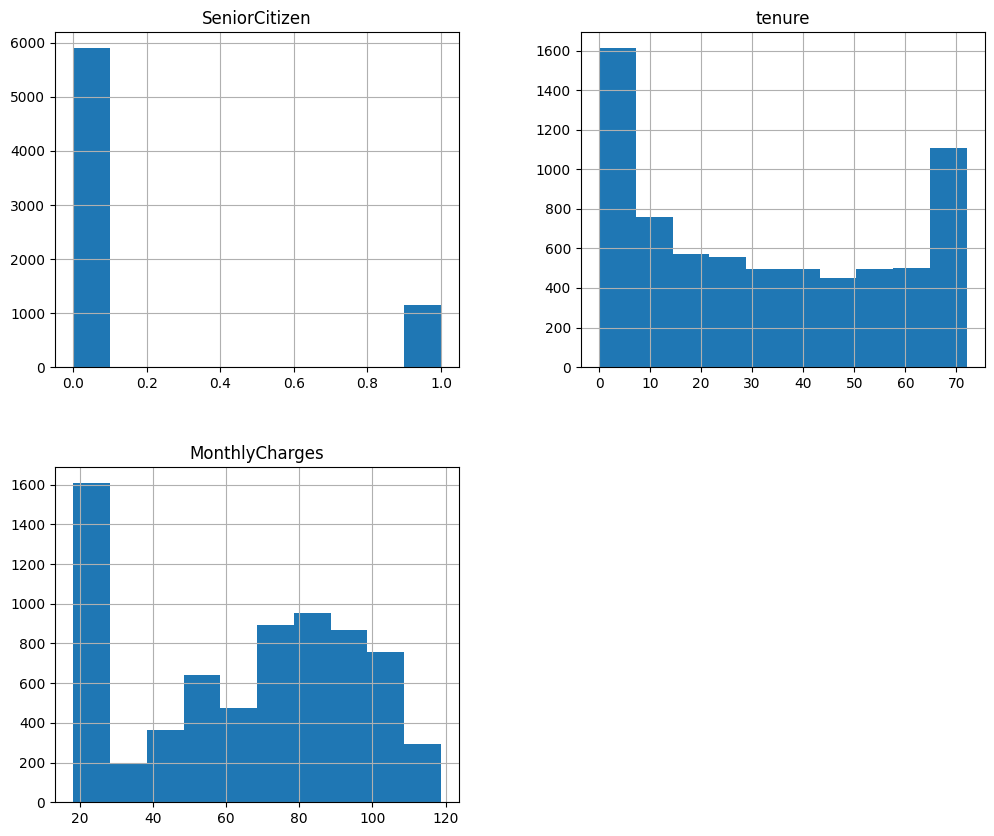

In [ ]:
df.hist(figsize=(12,10))
plt.show()

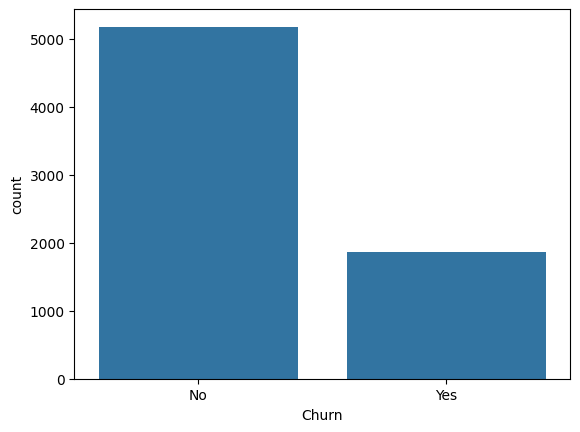

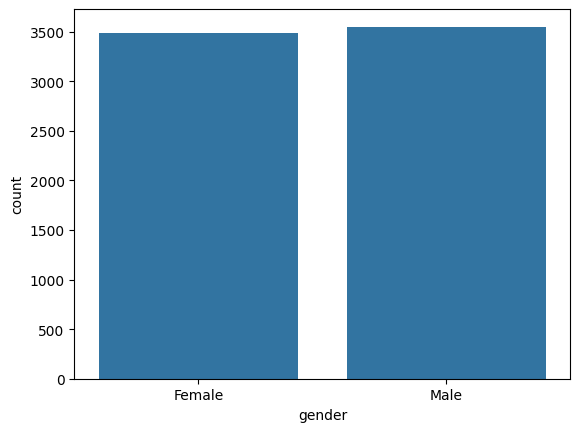

In [ ]:
sns.countplot(x='Churn', data=df)
plt.show()

sns.countplot(x='gender', data=df)
plt.show()

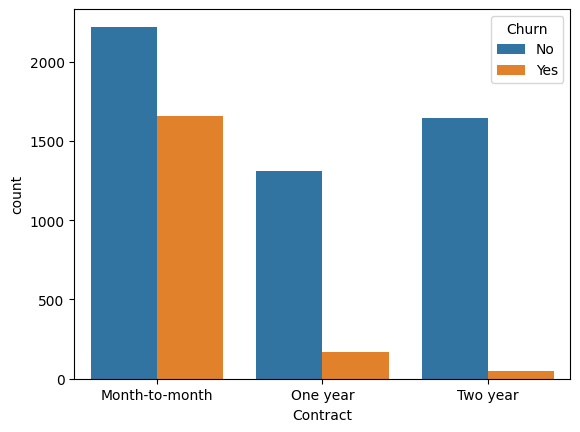

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()


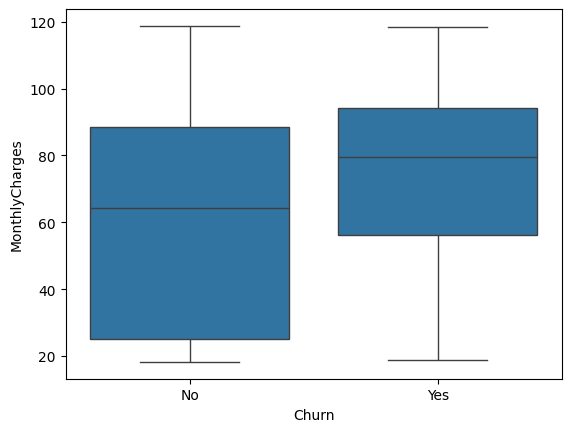

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

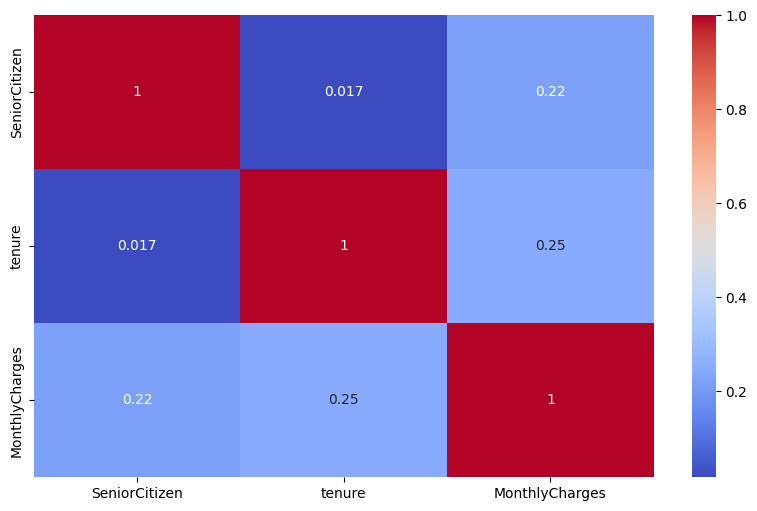

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

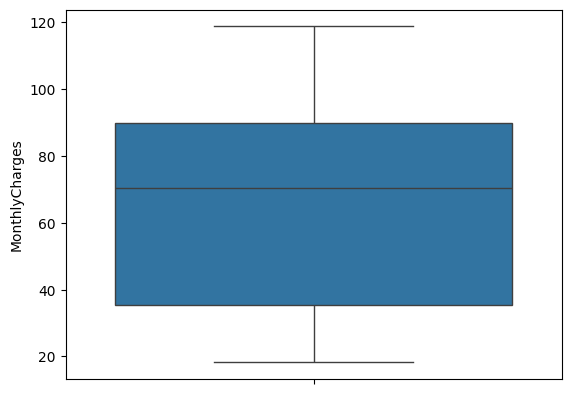

In [ ]:
sns.boxplot(df['MonthlyCharges'])
plt.show()

In [ ]:
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)

IQR = Q3 - Q1

df = df[(df['MonthlyCharges'] >= Q1 - 1.5*IQR) &
        (df['MonthlyCharges'] <= Q3 + 1.5*IQR)]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train, y_train = sm.fit_resample(X_train, y_train)

In [ ]:
lr = LogisticRegression(max_iter=1000)
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
svc = SVC()
gb = GradientBoostingClassifier()

models = [lr, knn, dt, rf, svc, gb]

for model in models:
    model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:


for model in models:
    pred = model.predict(X_test)
    print(model.__class__.__name__)
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall:", recall_score(y_test, pred))
    print("F1:", f1_score(y_test, pred))
    print("----------------------")

LogisticRegression
Accuracy: 0.78708303761533
Precision: 0.5650319829424307
Recall: 0.7340720221606648
F1: 0.6385542168674698
----------------------
KNeighborsClassifier
Accuracy: 0.595457771469127
Precision: 0.32318104906937395
Recall: 0.5290858725761773
F1: 0.4012605042016807
----------------------
DecisionTreeClassifier
Accuracy: 0.7175301632363378
Precision: 0.4531645569620253
Recall: 0.49584487534626037
F1: 0.47354497354497355
----------------------
RandomForestClassifier
Accuracy: 0.7970191625266146
Precision: 0.6099706744868035
Recall: 0.5761772853185596
F1: 0.5925925925925926
----------------------
SVC
Accuracy: 0.5074520936834634
Precision: 0.2728512960436562
Recall: 0.554016620498615
F1: 0.3656307129798903
----------------------
GradientBoostingClassifier
Accuracy: 0.794180269694819
Precision: 0.589873417721519
Recall: 0.6454293628808865
F1: 0.6164021164021164
----------------------


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 200}


In [ ]:
results = []

for model in models:
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results.append([model.__class__.__name__, acc])

import pandas as pd

result_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])
print(result_df)

                        Model  Accuracy
0          LogisticRegression  0.787083
1        KNeighborsClassifier  0.595458
2      DecisionTreeClassifier  0.717530
3      RandomForestClassifier  0.797019
4                         SVC  0.507452
5  GradientBoostingClassifier  0.794180


In [ ]:
y_pred = rf.predict(X_test)

In [34]:

output = ["Leave" if i == 1 else "Not Leave" for i in y_pred]

print(output[:10])

['Not Leave', 'Leave', 'Not Leave', 'Not Leave', 'Not Leave', 'Not Leave', 'Leave', 'Not Leave', 'Leave', 'Leave']


In [35]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

# Convert both
result["Actual"] = result["Actual"].apply(lambda x: "Leave" if x == 1 else "Not Leave")
result["Predicted"] = result["Predicted"].apply(lambda x: "Leave" if x == 1 else "Not Leave")

print(result.head(10))

      Actual  Predicted
0  Not Leave  Not Leave
1  Not Leave      Leave
2  Not Leave  Not Leave
3  Not Leave  Not Leave
4  Not Leave  Not Leave
5  Not Leave  Not Leave
6      Leave      Leave
7  Not Leave  Not Leave
8  Not Leave      Leave
9      Leave      Leave


In [36]:

new_customer = X_test.iloc[0].values.reshape(1, -1)

prediction = rf.predict(new_customer)

if prediction[0] == 1:
    print("Customer will LEAVE ❌")
else:
    print("Customer will NOT LEAVE ✅")

Customer will NOT LEAVE ✅


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
